# Multi-subject Variation on SVMs
Since my last exploration resulted on better results considering a variable number of subjects.<br>
We will use a XDAWN preprocessing and linear kernel on the SVM.<br>
We found no improvement when increasing subject number. Otherwise, there was some decrease on accuracy. <br>
No hypotesis test were made, but I believe there is a almost zero cahnce of there being a increase - at least on this data.

In [1]:
#Lib
import sys
sys.path.append("/home/rffl/files/eegconv/k-class")

import pyriemann as rmn
import numpy as np
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import kclass_lsubgen
import matplotlib.pyplot as plt

In [2]:
# Parameters
classvec = [i+1 for i in range(5)]
prop = 0.75
metric = "riemann"
estimator = "lwf"
xDAWN_filters = 5

## 1 subject

### Data Gen.

In [3]:
subvec = [2]

train_path, test_path = kclass_lsubgen.generatedataset(classvec, subvec, prop, False)

# Data vectors
X_train = np.load(train_path, allow_pickle=True) # signals
X_test  = np.load(test_path, allow_pickle=True)
y_train = np.array([])           # labels
part = len(X_train) // len(classvec)
for i in range(len(classvec)):
    y_train = np.concatenate([y_train, i * np.ones(part, dtype=np.int64)])

y_test = np.array([])
part = len(X_test) // len(classvec)
for i in range(len(classvec)):
    y_test = np.concatenate([y_test, i * np.ones(part, dtype=np.int64)])

Saved ./kclass-lsubtrain.npy shape = (300, 17, 100)
Saved ./kclass-lsubtest.npy shape = (100, 17, 100)


### Training

Acc 0.65


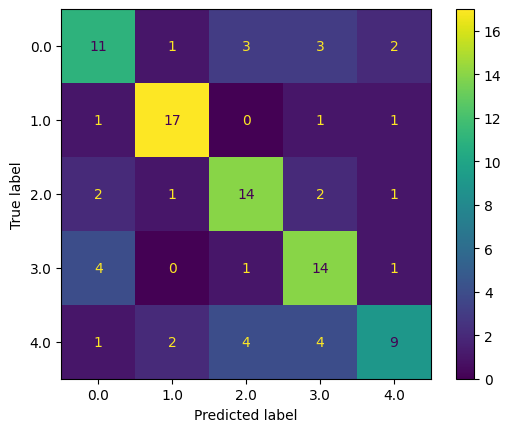

In [4]:
# XDAWN
cov = rmn.estimation.XdawnCovariances(nfilter=xDAWN_filters, estimator=estimator)
X_train_cov = cov.fit_transform(X_train, y_train)
X_test_cov = cov.transform(X_test)

# Classifier
classifier = sklearn.svm.LinearSVC()
X_tang_train = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_train_cov)
X_tang_test = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_test_cov)
classifier.fit(X_tang_train, y_train)
y_pred = classifier.predict(X_tang_test)

corr = 0
for i in range(len(y_pred)):
    if y_pred[i] == y_test[i]:
        corr += 1

print("Acc " + str(corr/len(y_pred)))

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

## 3 subjects

### Data Gen.

In [ ]:
subvec = [1, 6, 7]

train_path, test_path = kclass_lsubgen.generatedataset(classvec, subvec, prop, False)

# Data vectors
X_train = np.load(train_path, allow_pickle=True) # signals
X_test  = np.load(test_path, allow_pickle=True)
y_train = np.array([])           # labels
part = len(X_train) // len(classvec)
for i in range(len(classvec)):
    y_train = np.concatenate([y_train, i * np.ones(part, dtype=np.int64)])

y_test = np.array([])
part = len(X_test) // len(classvec)
for i in range(len(classvec)):
    y_test = np.concatenate([y_test, i * np.ones(part, dtype=np.int64)])

Saved ./kclass-lsubtrain.npy shape = (900, 17, 100)
Saved ./kclass-lsubtest.npy shape = (300, 17, 100)


### Training

Acc 0.67


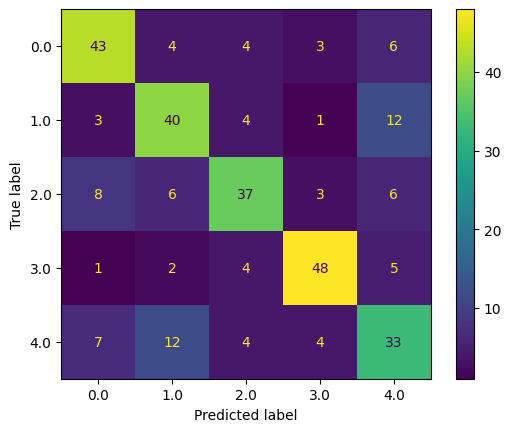

In [ ]:
# XDAWN
cov = rmn.estimation.XdawnCovariances(nfilter=xDAWN_filters, estimator=estimator)
X_train_cov = cov.fit_transform(X_train, y_train)
X_test_cov = cov.transform(X_test)

# Classifier
classifier = sklearn.svm.LinearSVC()
X_tang_train = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_train_cov)
X_tang_test = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_test_cov)
classifier.fit(X_tang_train, y_train)
y_pred = classifier.predict(X_tang_test)

corr = 0
for i in range(len(y_pred)):
    if y_pred[i] == y_test[i]:
        corr += 1

print("Acc " + str(corr/len(y_pred)))

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

## 5 subjects

### Data Gen.

In [7]:
subvec = [1, 2, 5, 6, 7]

train_path, test_path = kclass_lsubgen.generatedataset(classvec, subvec, prop, False)

# Data vectors
X_train = np.load(train_path, allow_pickle=True) # signals
X_test  = np.load(test_path, allow_pickle=True)
y_train = np.array([])           # labels
part = len(X_train) // len(classvec)
for i in range(len(classvec)):
    y_train = np.concatenate([y_train, i * np.ones(part, dtype=np.int64)])

y_test = np.array([])
part = len(X_test) // len(classvec)
for i in range(len(classvec)):
    y_test = np.concatenate([y_test, i * np.ones(part, dtype=np.int64)])

Saved ./kclass-lsubtrain.npy shape = (1500, 17, 100)
Saved ./kclass-lsubtest.npy shape = (500, 17, 100)


### Training

Acc 0.594


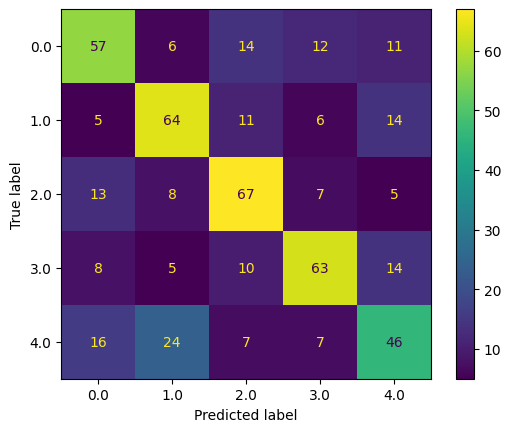

In [8]:
# XDAWN
cov = rmn.estimation.XdawnCovariances(nfilter=xDAWN_filters, estimator=estimator)
X_train_cov = cov.fit_transform(X_train, y_train)
X_test_cov = cov.transform(X_test)

# Classifier
classifier = sklearn.svm.LinearSVC()
X_tang_train = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_train_cov)
X_tang_test = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_test_cov)
classifier.fit(X_tang_train, y_train)
y_pred = classifier.predict(X_tang_test)

corr = 0
for i in range(len(y_pred)):
    if y_pred[i] == y_test[i]:
        corr += 1

print("Acc " + str(corr/len(y_pred)))

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

## 7 subjects

### Data Gen.

In [9]:
subvec = [1, 2, 5, 6, 7, 9, 10]

train_path, test_path = kclass_lsubgen.generatedataset(classvec, subvec, prop, False)

# Data vectors
X_train = np.load(train_path, allow_pickle=True) # signals
X_test  = np.load(test_path, allow_pickle=True)
y_train = np.array([])           # labels
part = len(X_train) // len(classvec)
for i in range(len(classvec)):
    y_train = np.concatenate([y_train, i * np.ones(part, dtype=np.int64)])

y_test = np.array([])
part = len(X_test) // len(classvec)
for i in range(len(classvec)):
    y_test = np.concatenate([y_test, i * np.ones(part, dtype=np.int64)])

Saved ./kclass-lsubtrain.npy shape = (2100, 17, 100)
Saved ./kclass-lsubtest.npy shape = (700, 17, 100)


### Training

Acc 0.6128571428571429


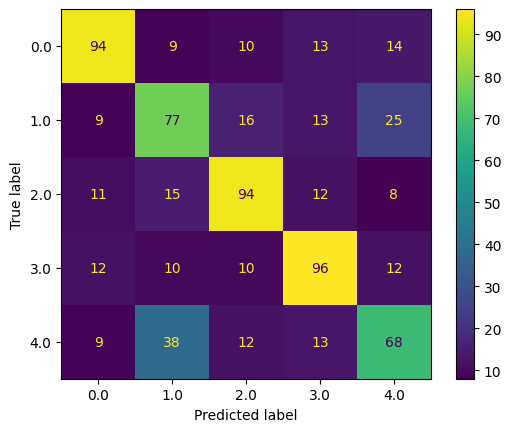

In [10]:
# XDAWN
cov = rmn.estimation.XdawnCovariances(nfilter=xDAWN_filters, estimator=estimator)
X_train_cov = cov.fit_transform(X_train, y_train)
X_test_cov = cov.transform(X_test)

# Classifier
classifier = sklearn.svm.LinearSVC()
X_tang_train = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_train_cov)
X_tang_test = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_test_cov)
classifier.fit(X_tang_train, y_train)
y_pred = classifier.predict(X_tang_test)

corr = 0
for i in range(len(y_pred)):
    if y_pred[i] == y_test[i]:
        corr += 1

print("Acc " + str(corr/len(y_pred)))

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

## 10 subjects

### Data Gen.

In [11]:
subvec = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

train_path, test_path = kclass_lsubgen.generatedataset(classvec, subvec, prop, False)

# Data vectors
X_train = np.load(train_path, allow_pickle=True) # signals
X_test  = np.load(test_path, allow_pickle=True)
y_train = np.array([])           # labels
part = len(X_train) // len(classvec)
for i in range(len(classvec)):
    y_train = np.concatenate([y_train, i * np.ones(part, dtype=np.int64)])

y_test = np.array([])
part = len(X_test) // len(classvec)
for i in range(len(classvec)):
    y_test = np.concatenate([y_test, i * np.ones(part, dtype=np.int64)])

Saved ./kclass-lsubtrain.npy shape = (3000, 17, 100)
Saved ./kclass-lsubtest.npy shape = (1000, 17, 100)


### Training

Acc 0.621


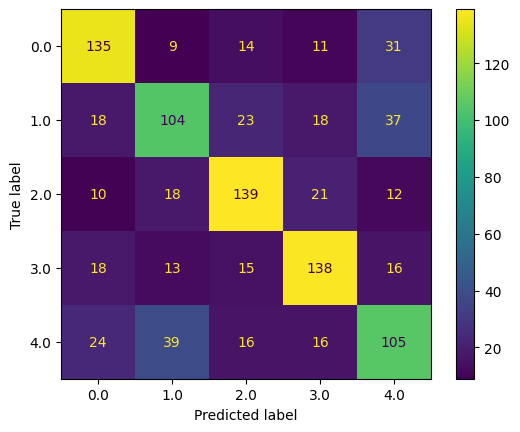

In [12]:
# XDAWN
cov = rmn.estimation.XdawnCovariances(nfilter=xDAWN_filters, estimator=estimator)
X_train_cov = cov.fit_transform(X_train, y_train)
X_test_cov = cov.transform(X_test)

# Classifier
classifier = sklearn.svm.LinearSVC()
X_tang_train = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_train_cov)
X_tang_test = rmn.tangentspace.TangentSpace(metric=metric).fit_transform(X_test_cov)
classifier.fit(X_tang_train, y_train)
y_pred = classifier.predict(X_tang_test)

corr = 0
for i in range(len(y_pred)):
    if y_pred[i] == y_test[i]:
        corr += 1

print("Acc " + str(corr/len(y_pred)))

cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()